In [14]:
# Cell 1: Environment Setup and Library Imports
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)
print("Environment initialized successfully.")

Environment initialized successfully.


In [15]:
# Cell 2: Robust Load Dataset and Perform EDA
import os
import glob
import pandas as pd

# Check for the file or search for any matching csv
csv_files = glob.glob("*.csv")
print("Found CSV files in session:", csv_files)

# Target file possibilities
possible_names = [
    "final dataset  for kaggle.csv",
    "final dataset for kaggle.csv",
    "final_dataset_for_kaggle.csv"
]

dataset_path = None
for name in possible_names:
    if os.path.exists(name):
        dataset_path = name
        break

if not dataset_path and csv_files:
    dataset_path = csv_files[0]

if not dataset_path:
    # If not found, open an interactive file upload prompt
    print("CSV not found in directory. Please upload it below:")
    from google.colab import files
    uploaded = files.upload()
    dataset_path = list(uploaded.keys())[0]

print(f"Loading dataset from: '{dataset_path}'")
df = pd.read_csv(dataset_path)

print("=" * 60)
print(f"Dataset Overview: {df.shape[0]} rows, {df.shape[1]} columns")
print("=" * 60)
print("\nMissing Values per Feature:\n", df.isnull().sum())

# Strip whitespace from string columns
text_cols = ['CITY', 'STATE', 'SERVICE HISTORY', 'COMMON PROBLEM', 'SOLUTION USED', 'VEHICAL COMPANY']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print("\n--- Distribution Summary ---")
print(f"Unique Vehicle Companies: {df['VEHICAL COMPANY'].nunique()}")
print(f"Unique Common Problems:  {df['COMMON PROBLEM'].nunique()}")
print(f"Unique Workshop Solutions: {df['SOLUTION USED'].nunique()}")

print("\nTop 5 Common Vehicle Faults:")
print(df['COMMON PROBLEM'].value_counts().head(5))

print("\nTop 5 Workshop Solutions Applied:")
print(df['SOLUTION USED'].value_counts().head(5))

Found CSV files in session: ['final dataset  for kaggle.csv']
Loading dataset from: 'final dataset  for kaggle.csv'
Dataset Overview: 508 rows, 7 columns

Missing Values per Feature:
 CUSTOMER ID        0
CITY               0
STATE              0
SERVICE HISTORY    0
COMMON PROBLEM     0
SOLUTION USED      0
VEHICAL COMPANY    0
dtype: int64

--- Distribution Summary ---
Unique Vehicle Companies: 72
Unique Common Problems:  52
Unique Workshop Solutions: 44

Top 5 Common Vehicle Faults:
COMMON PROBLEM
Cloudy headlights    49
Brake noise          45
Exhaust noise        37
Tire wear            34
Fluid leak           30
Name: count, dtype: int64

Top 5 Workshop Solutions Applied:
SOLUTION USED
Headlight restoration        101
Brake pad replacement         50
Exhaust system repair         44
Fluid replacement             30
Transmission fluid change     25
Name: count, dtype: int64


/tmp/ipykernel_1957/3015926086.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1957/3015926086.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


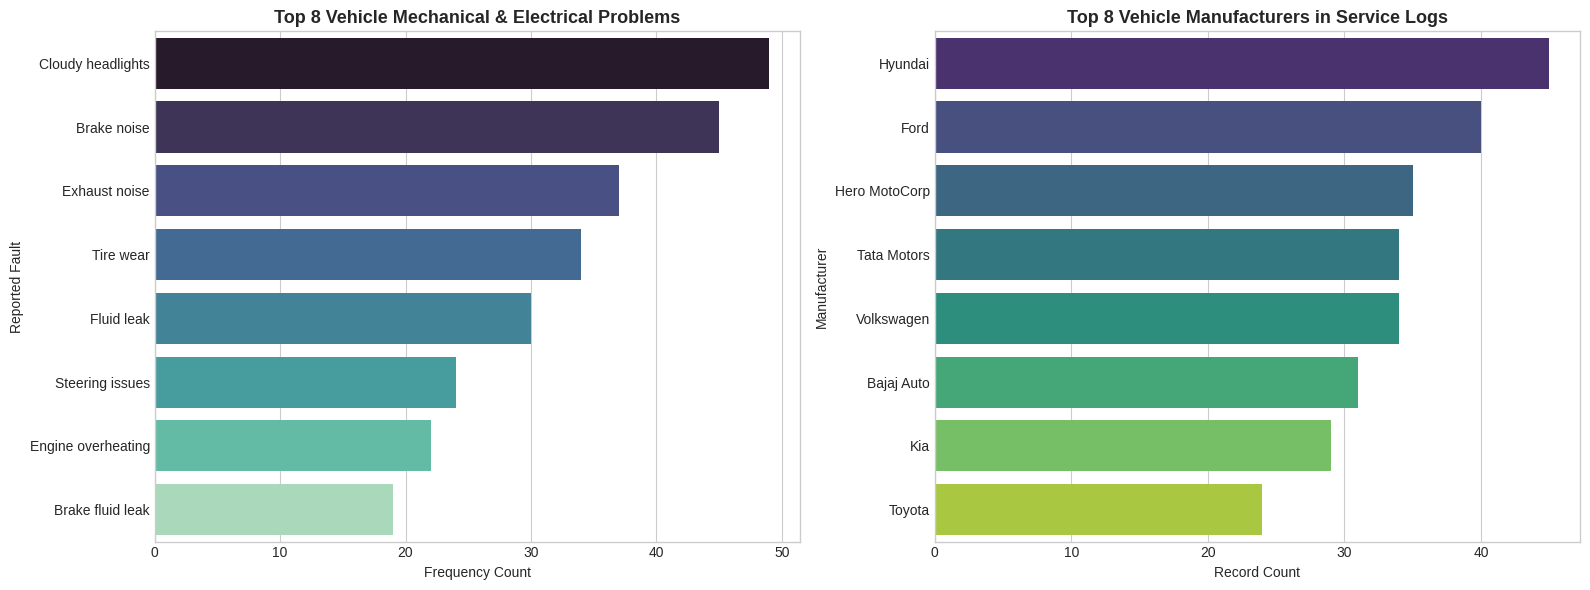

In [16]:
# Cell 3: Visualizing Top Problems and Vehicle Brands
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 8 Vehicle Problems
top_problems = df['COMMON PROBLEM'].value_counts().head(8)
sns.barplot(
    y=top_problems.index,
    x=top_problems.values,
    ax=axes[0],
    palette="mako"
)
axes[0].set_title("Top 8 Vehicle Mechanical & Electrical Problems", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Frequency Count")
axes[0].set_ylabel("Reported Fault")

# Plot 2: Top 8 Vehicle Manufacturers
top_companies = df['VEHICAL COMPANY'].value_counts().head(8)
sns.barplot(
    y=top_companies.index,
    x=top_companies.values,
    ax=axes[1],
    palette="viridis"
)
axes[1].set_title("Top 8 Vehicle Manufacturers in Service Logs", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Record Count")
axes[1].set_ylabel("Manufacturer")

plt.tight_layout()
plt.savefig("outputs/eda_distributions.png", dpi=300)
plt.show()

In [17]:
# Cell 4: Feature Synthesis and Stratified Splitting

# Mitigate class imbalance: aggregate rare solutions (< 5 instances)
val_counts = df['SOLUTION USED'].value_counts()
df['TARGET'] = df['SOLUTION USED'].apply(lambda x: x if val_counts[x] >= 5 else 'Other / Specialized Repair')

# Form composite input feature vector
df['INPUT_FEATURES'] = (
    "Fault: " + df['COMMON PROBLEM'] +
    " | Brand: " + df['VEHICAL COMPANY'] +
    " | Prior Service: " + df['SERVICE HISTORY']
)

X = df['INPUT_FEATURES']
y = df['TARGET']

# Stratified 80/20 train-test partition
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training instances: {len(X_train)}")
print(f"Testing instances:  {len(X_test)}")
print(f"Target classes:     {y.nunique()}")

Training instances: 406
Testing instances:  102
Target classes:     21


In [18]:
# Cell 5: Machine Learning Pipeline Benchmarking

models = {
    "Logistic Regression (TF-IDF)": Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest (TF-IDF)": Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "Gradient Boosting (TF-IDF)": Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
        ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

evaluation_records = []
fitted_models = {}

print("Training candidate models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    evaluation_records.append({
        "Model Architecture": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Weighted F1-Score": round(f1, 4)
    })
    fitted_models[name] = model

# Display benchmark table
results_summary = pd.DataFrame(evaluation_records)
print("\n" + "=" * 60)
print("BENCHMARK EVALUATION SUMMARY")
print("=" * 60)
print(results_summary.to_string(index=False))

Training candidate models...

BENCHMARK EVALUATION SUMMARY
          Model Architecture  Accuracy (%)  Weighted F1-Score
Logistic Regression (TF-IDF)         95.10             0.9454
      Random Forest (TF-IDF)         94.12             0.9352
  Gradient Boosting (TF-IDF)         92.16             0.9159


In [19]:
# Cell 6: Classification Report for Best Model and Model Export
best_model_name = "Logistic Regression (TF-IDF)"
best_pipeline = fitted_models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

print(f"Detailed Classification Report: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, zero_division=0))

# Save the trained model to disk
model_save_path = "models/best_vehicle_diagnostic_model.pkl"
joblib.dump(best_pipeline, model_save_path)
print(f"Model successfully saved to '{model_save_path}'.")

Detailed Classification Report: Logistic Regression (TF-IDF)

                             precision    recall  f1-score   support

        Battery replacement       1.00      1.00      1.00         3
                Body repair       1.00      1.00      1.00         1
    Brake fluid replacement       1.00      1.00      1.00         4
      Brake pad replacement       0.91      1.00      0.95        10
          Brake replacement       1.00      0.50      0.67         2
       Cooling system flush       0.80      1.00      0.89         4
            Diagnostic scan       1.00      1.00      1.00         5
      Exhaust system repair       0.90      1.00      0.95         9
          Fluid replacement       1.00      1.00      1.00         6
       Fuel system cleaning       1.00      1.00      1.00         1
      Headlight restoration       1.00      1.00      1.00        20
            Oil replacement       1.00      1.00      1.00         1
 Other / Specialized Repair       0.67  

In [20]:
# Cell 7: Verification with Unseen Sample Diagnoses
sample_cases = [
    "Fault: Brake noise | Brand: Maruti Suzuki | Prior Service: Oil Change",
    "Fault: Cloudy headlights | Brand: Hyundai | Prior Service: Routine Checkup",
    "Fault: Engine overheating | Brand: Tata Motors | Prior Service: Radiator Flush"
]

print("Running sample real-time diagnostics:\n")
predictions = best_pipeline.predict(sample_cases)
for case, pred in zip(sample_cases, predictions):
    print(f"Input: {case}")
    print(f"--> Recommended Workshop Solution: {pred}\n")

Running sample real-time diagnostics:

Input: Fault: Brake noise | Brand: Maruti Suzuki | Prior Service: Oil Change
--> Recommended Workshop Solution: Brake pad replacement

Input: Fault: Cloudy headlights | Brand: Hyundai | Prior Service: Routine Checkup
--> Recommended Workshop Solution: Headlight restoration

Input: Fault: Engine overheating | Brand: Tata Motors | Prior Service: Radiator Flush
--> Recommended Workshop Solution: Other / Specialized Repair

